In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
# Load processed dataset
terror_df = pd.read_csv(
    "../data/processed/terrorism_cleaned.csv",
    parse_dates=["date"]
)
terror_df.head()

,eventid,iyear,imonth,iday,country_txt,region_txt,provstate,city,latitude,longitude,...,gname,weaptype1_txt,nkill,nwound,date,casualties,attack_success,suicide_attack,decade,high_casualty
0,197000000001,1970,7,2,Dominican Republic,Central America & Caribbean,National,Santo Domingo,18.456792,-69.951164,...,MANO-D,Unknown,1.0,0.0,1970-07-02,1.0,Successful,No,1970s,No
1,197000000002,1970,1,1,Mexico,North America,Federal,Mexico city,19.371887,-99.086624,...,23rd of September Communist League,Unknown,0.0,0.0,1970-01-01,0.0,Successful,No,1970s,No
2,197001000001,1970,1,1,Philippines,Southeast Asia,Tarlac,Unknown,15.478598,120.599741,...,Unknown Group,Unknown,1.0,0.0,1970-01-01,1.0,Successful,No,1970s,No
3,197001000002,1970,1,1,Greece,Western Europe,Attica,Athens,37.997490,23.762728,...,Unknown Group,Explosives,0.0,0.0,1970-01-01,0.0,Successful,No,1970s,No
4,197001000003,1970,1,1,Japan,East Asia,Fukouka,Fukouka,33.580412,130.396361,...,Unknown Group,Incendiary,0.0,0.0,1970-01-01,0.0,Successful,No,1970s,No


In [4]:
# Count incidents by decade
decade_counts = (
    terror_df["decade"]
    .value_counts()
    .sort_index()
)

decade_counts

decade
1970s      9913
1980s     31156
1990s     28765
2000s     25057
2010s    106377
2020s      8438
Name: count, dtype: int64

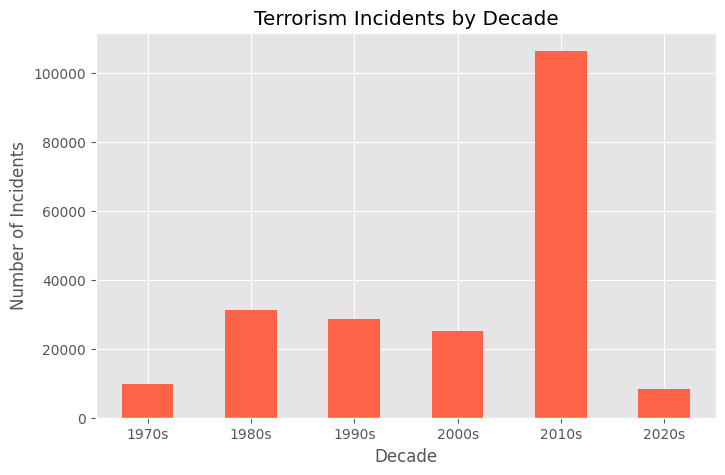

In [10]:
# Plot incidents by decade
plt.figure(figsize=(8,5))

decade_counts.plot(
    kind="bar",
    color="tomato"
)

plt.xlabel("Decade")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.title("Terrorism Incidents by Decade")

plt.show()

In [11]:
# Calculate attack outcomes
success_counts = (
    terror_df["attack_success"]
    .value_counts()
)

success_counts

attack_success
Successful    185302
Failed         24404
Name: count, dtype: int64

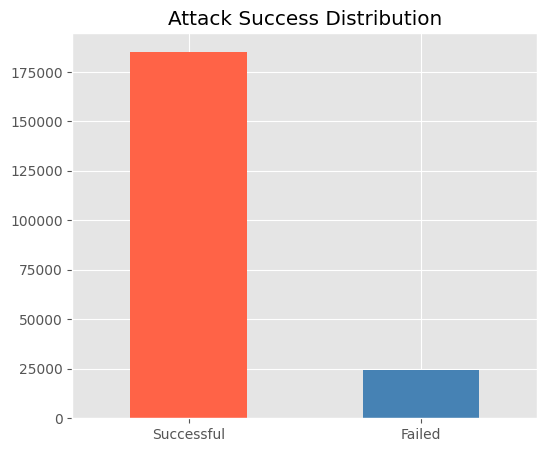

In [16]:
# Plot attack success
plt.figure(figsize=(6,5))

success_counts.plot(
    kind="bar",
    color=["tomato","steelblue"]
)

plt.xlabel("")
plt.title("Attack Success Distribution")

plt.xticks(rotation=0)

plt.show()

In [17]:
# Count suicide attacks
suicide_counts = (
    terror_df["suicide_attack"]
    .value_counts()
)

suicide_counts

suicide_attack
No     202268
Yes      7438
Name: count, dtype: int64

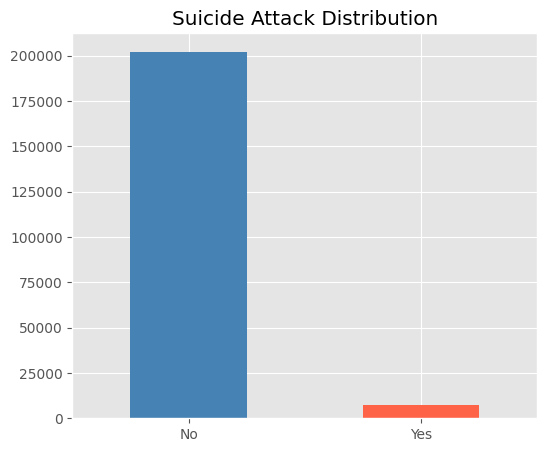

In [22]:
# Plot suicide attack distribution
plt.figure(figsize=(6,5))

suicide_counts.plot(
    kind="bar",
    color=["steelblue","tomato"]
)

plt.ylabel("")
plt.xlabel("")
plt.title("Suicide Attack Distribution")

plt.xticks(rotation=0)

plt.show()

In [23]:
# Count high casualty incidents
high_casualty_counts = (
    terror_df["high_casualty"]
    .value_counts()
)

high_casualty_counts

high_casualty
No     206759
Yes      2947
Name: count, dtype: int64

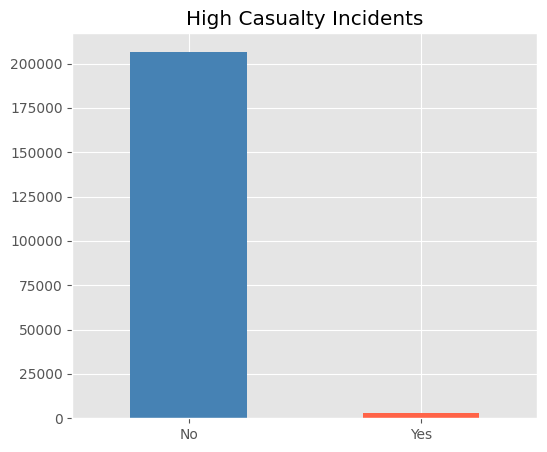

In [26]:
# Plot high casualty events
plt.figure(figsize=(6,5))

high_casualty_counts.plot(
    kind="bar",
    color=["steelblue","tomato"]
)

plt.ylabel("")
plt.xlabel("")
plt.title("High Casualty Incidents")

plt.xticks(rotation=0)

plt.show()

In [49]:
# Create a dataframe with readable column names
corr_df = terror_df[
    ["nkill", "nwound", "success", "suicide"]
].rename(
    columns={
        "nkill": "Fatalities",
        "nwound": "Injuries",
        "success": "Attack Success",
        "suicide": "Suicide Attack"
    }
)
corr_df

,Fatalities,Injuries,Attack Success,Suicide Attack
0,1.0,0.0,1,0
1,0.0,0.0,1,0
2,1.0,0.0,1,0
3,0.0,0.0,1,0
4,0.0,0.0,1,0
...,...,...,...,...
209701,0.0,0.0,1,0
209702,0.0,0.0,1,0
209703,0.0,0.0,1,0
209704,1.0,0.0,1,0


In [50]:
# Compute correlation matrix
corr_matrix = corr_df.corr()

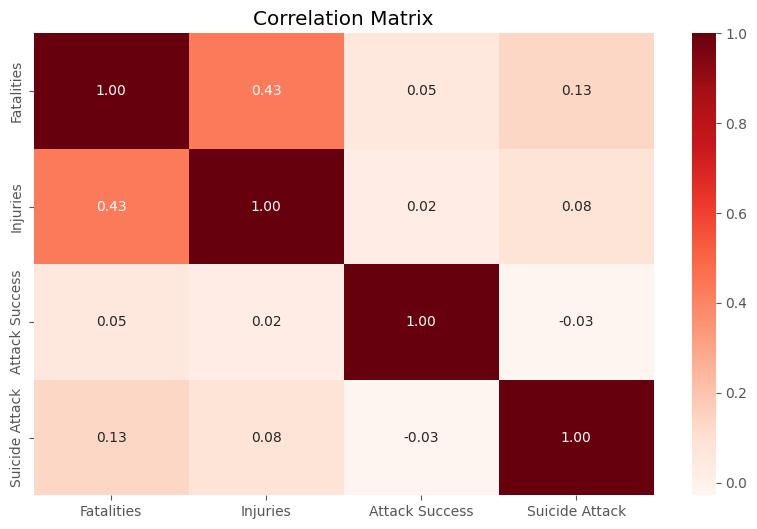

In [53]:
# Plot correlation matrix
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Correlation Matrix")

plt.show()

In [31]:
# Calculate fatalities by country
hot_countries = (
    terror_df
    .groupby("country_txt")["nkill"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

hot_countries

country_txt
Iraq           81675.0
Afghanistan    67549.0
Nigeria        29093.0
Pakistan       25259.0
India          20358.0
Syria          18860.0
Sri Lanka      15588.0
Colombia       15135.0
Somalia        13175.0
Yemen          12842.0
Name: nkill, dtype: float64

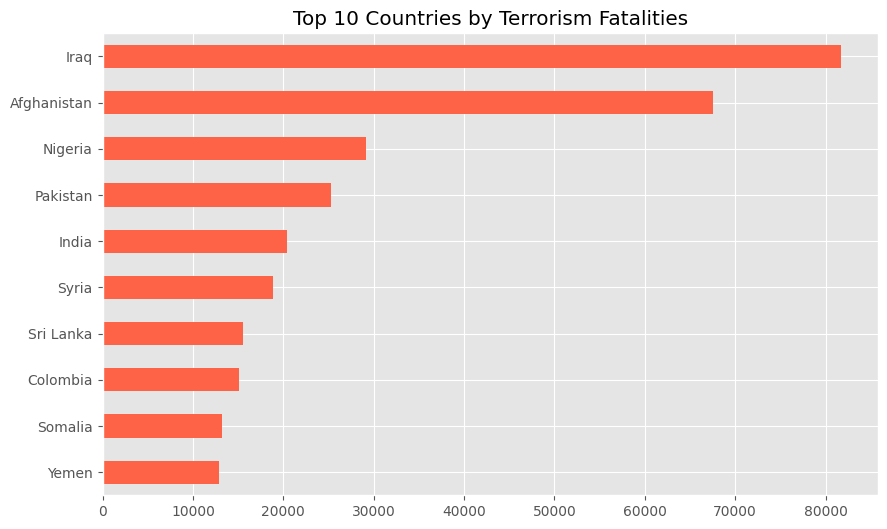

In [37]:
# Plot hot countries
plt.figure(figsize=(10,6))

hot_countries.sort_values().plot(
    kind="barh",
    color="tomato"
)

plt.xlabel("")
plt.ylabel("")
plt.title("Top 10 Countries by Terrorism Fatalities")

plt.show()

In [35]:
# Calculate fatalities by group
deadliest_groups = (
    terror_df[
        terror_df["gname"] != "Unknown Group"
    ]
    .groupby("gname")["nkill"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

deadliest_groups

gname
Taliban                                             54118.0
Islamic State of Iraq and the Levant (ISIL)         43352.0
Boko Haram                                          25528.0
Al-Shabaab                                          12277.0
Shining Path (SL)                                   11608.0
Liberation Tigers of Tamil Eelam (LTTE)             10778.0
Farabundo Marti National Liberation Front (FMLN)     8065.0
Nicaraguan Democratic Force (FDN)                    6662.0
Houthi extremists (Ansar Allah)                      6420.0
Tehrik-i-Taliban Pakistan (TTP)                      6344.0
Name: nkill, dtype: float64

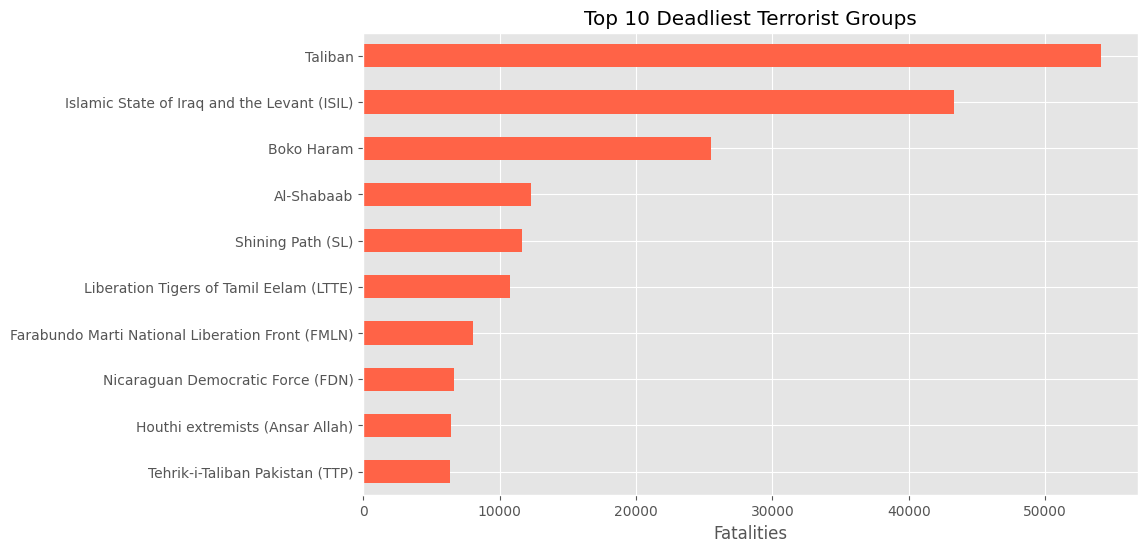

In [36]:
# Plot deadliest groups
plt.figure(figsize=(10,6))

deadliest_groups.sort_values().plot(
    kind="barh",
    color="tomato"
)

plt.xlabel("Fatalities")
plt.ylabel("")
plt.title("Top 10 Deadliest Terrorist Groups")

plt.show()